<a href="https://colab.research.google.com/github/brishti-c/undergrad_ml_assignments/blob/main/04_assignment_regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

Adding a penalty to mean squared error discourages the model from using large coefficients, which typically correspond to overly complex or overly sensitive fits to the training data. In other words, penalizing the size of parameters (either absolute values or squares) makes the model prioritize stability and general patterns over exact fits.

2. How does regularization provide a way of exploring the bias-variance trade-off?

Regularization directly controls the bias-variance trade-off. As the penalty increases, the model becomes simpler, which increases bias (it may underfit) but reduces variance (it becomes less sensitive to noise in the data).

3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?

The key difference between LASSO (L1) and Ridge (L2) regression is how they penalize coefficients. Ridge shrinks coefficients continuously toward zero but rarely makes them exactly zero, so it keeps all variables in the model. LASSO, on the other hand, can shrink some coefficients exactly to zero, effectively performing feature selection. As a result, LASSO produces sparse models, while Ridge produces dense ones.

4. How do we typically scale variables for use in regularized regression? Why?

We typically scale variables (e.g., using standardization to zero mean and unit variance) before applying regularization. This is important because the penalty depends on coefficient size, and without scaling, variables with larger natural scales would be penalized differently than smaller-scale variables. Standardizing ensures all features are treated equally.

5. How is the penalty $\alpha$ typically selected?

The penalty $\alpha$ is usually selected using cross-validation. We test a range of values and choose the one that minimizes validation error, ensuring the model generalizes well to unseen data.

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

When conducting cross-validation, we do not include the penalty term in the evaluation metric (e.g., MSE). This is because we care about predictive performance on unseen data, not the penalized objective function. The penalty is only used during training to control model complexity, not as part of the evaluation metric.

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, LassoCV, lasso_path
from sklearn.pipeline import Pipeline

! git clone https://github.com/brishti-c/scratchpad
%run ./scratchpad/get_data.py

fatal: destination path 'scratchpad' already exists and is not an empty directory.


<Figure size 640x480 with 0 Axes>

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [98]:
# Load data
df = pd.read_csv('./data/cars_hw.csv')

# Create Age variable
df['Age'] = 2026 - df['Make_Year']

# Prepare features
X = df[['Mileage_Run', 'Age']]
y = df['Price']

# Create polynomial features (degree 3)
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X)

# Z-score normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

# Get feature names
feature_names = poly.get_feature_names_out(['Mileage_Run', 'Age'])


In [99]:
# Linear regression
lr = LinearRegression()
lr.fit(X_scaled, y_scaled)

# Find interaction coefficient (Mileage_Run × Age)
interaction_idx = [i for i, name in enumerate(feature_names)
                   if 'Mileage_Run Age' in name][0]

print(f"Interaction coefficient (Mileage_Run × Age): {lr.coef_[interaction_idx]:.4f}")

Interaction coefficient (Mileage_Run × Age): -16.7121


In [100]:
# Alpha grid
alphas = np.logspace(1, 3, 20)  # 10 to 1000

# LassoCV with 20-fold CV
lasso_cv = LassoCV(
    alphas=alphas,
    cv=20,
    random_state=42,
    max_iter=20000,
    tol=1e-3
)
lasso_cv.fit(X_scaled, y)

print(f"\nOptimal alpha: {lasso_cv.alpha_:.6f}")
print(f"R² score at optimal alpha: {lasso_cv.score(X_scaled, y):.4f}")


Optimal alpha: 88.586679
R² score at optimal alpha: 0.3394


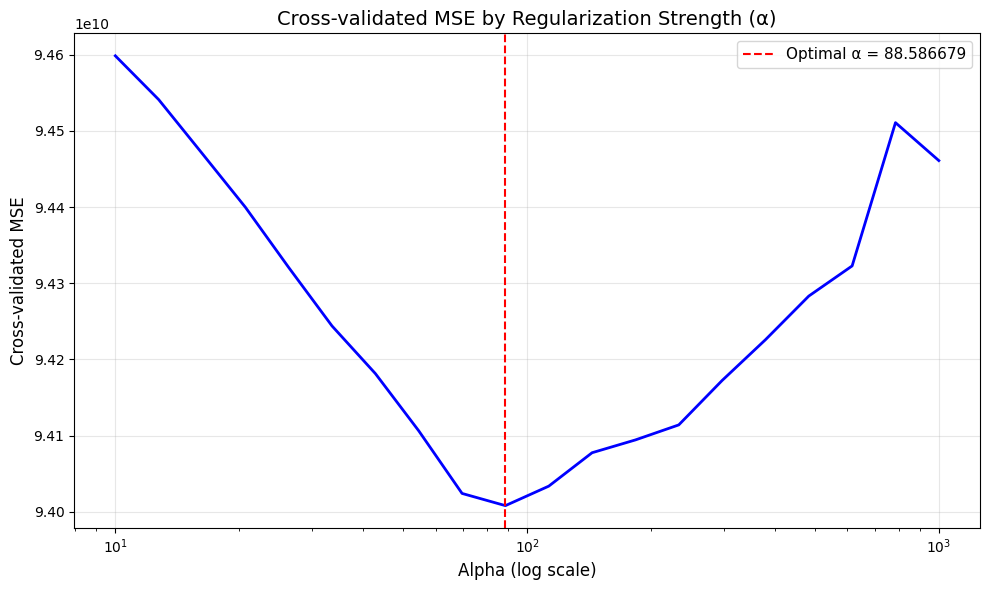

In [101]:
# Plot CV MSE vs Alpha
plt.figure(figsize=(10, 6))
plt.semilogx(lasso_cv.alphas_, lasso_cv.mse_path_.mean(axis=1), 'b-', linewidth=2)
plt.axvline(lasso_cv.alpha_, color='r', linestyle='--', label=f'Optimal α = {lasso_cv.alpha_:.6f}')
plt.xlabel('Alpha (log scale)', fontsize=12)
plt.ylabel('Cross-validated MSE', fontsize=12)
plt.title('Cross-validated MSE by Regularization Strength (α)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


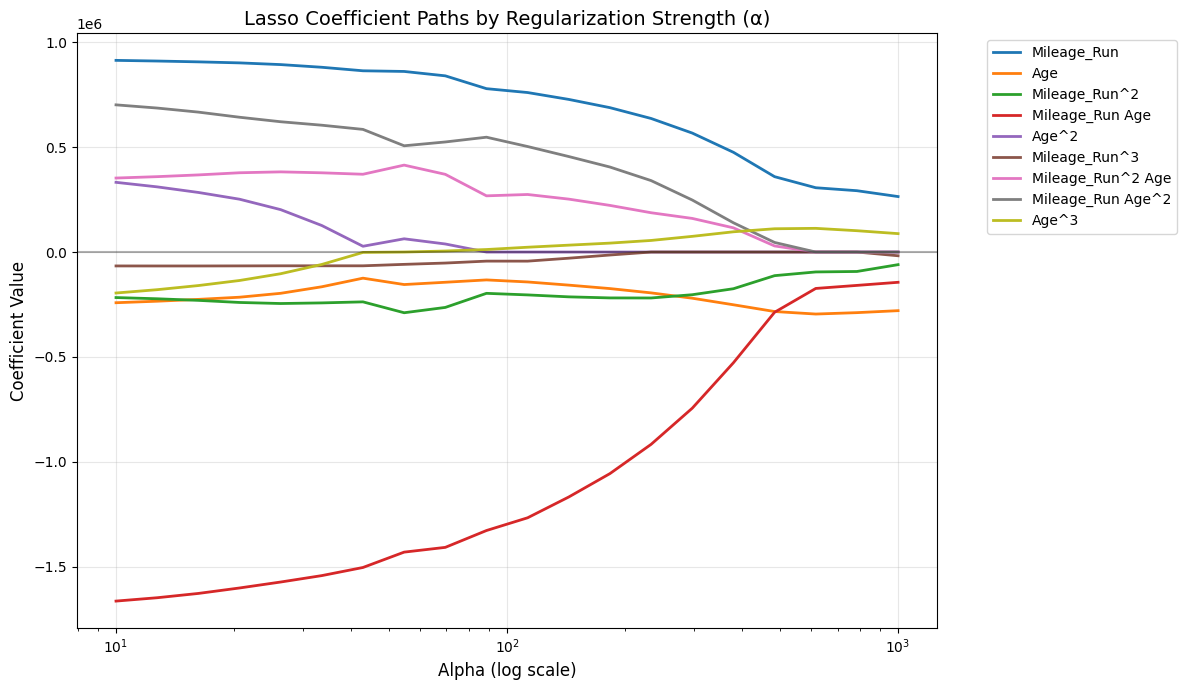

In [102]:
# Fit Lasso at each alpha to get coefficient paths
coef_paths = []
alphas_used = []

for alpha in alphas:
    lasso_temp = Lasso(
        alpha=alpha,
        random_state=42,
        max_iter=10000,
        tol=1e-3
    )
    lasso_temp.fit(X_scaled, y)
    coef_paths.append(lasso_temp.coef_)
    alphas_used.append(alpha)

coef_paths = np.array(coef_paths)

# Plot coefficient paths
plt.figure(figsize=(12, 7))
for i in range(len(feature_names)):
    plt.semilogx(alphas_used, coef_paths[:, i], label=feature_names[i], linewidth=2)

plt.xlabel('Alpha (log scale)', fontsize=12)
plt.ylabel('Coefficient Value', fontsize=12)
plt.title('Lasso Coefficient Paths by Regularization Strength (α)', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [103]:
# Fit optimal Lasso
lasso_opt = Lasso(
    alpha=lasso_cv.alpha_,
    random_state=42,
    max_iter=10000,
    tol=1e-3
)
lasso_opt.fit(X_scaled, y)

# Identify selected vs zero features
selected_mask = np.abs(lasso_opt.coef_) > 1e-6  # Tolerance for zero
selected_features = feature_names[selected_mask]
zero_features = feature_names[~selected_mask]

print(f"Total features: {len(feature_names)}")
print(f"Features selected (non-zero): {np.sum(selected_mask)}")
print(f"Features set to zero: {np.sum(~selected_mask)}")
print(f"Proportion zero: {np.sum(~selected_mask)/len(feature_names):.1%}")

print("\n✓ SELECTED FEATURES (non-zero coefficients):")
for feat in selected_features:
    coef_idx = np.where(feature_names == feat)[0][0]
    print(f"   • {feat}: {lasso_opt.coef_[coef_idx]:.4f}")

Total features: 9
Features selected (non-zero): 8
Features set to zero: 1
Proportion zero: 11.1%

✓ SELECTED FEATURES (non-zero coefficients):
   • Mileage_Run: 778736.2309
   • Age: -132863.2655
   • Mileage_Run^2: -196840.9170
   • Mileage_Run Age: -1327393.8644
   • Mileage_Run^3: -43291.6154
   • Mileage_Run^2 Age: 267911.9087
   • Mileage_Run Age^2: 547353.3156
   • Age^3: 12007.6889


**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [104]:
# Load data
df = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')

# Define feature groups
continuous_features = ['age', 'ejection_fraction', 'serum_creatinine']
categorical_features = ['anaemia', 'diabetes', 'high_blood_pressure', 'smoking']
target = 'DEATH_EVENT'

# Create third-degree polynomial features for continuous variables
poly_continuous = PolynomialFeatures(degree=3, include_bias=False, interaction_only=False)
X_continuous = poly_continuous.fit_transform(df[continuous_features])
cont_feature_names = poly_continuous.get_feature_names_out(continuous_features)

# Create interaction features for categorical variables (interaction_only=True)
poly_categorical = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
X_categorical = poly_categorical.fit_transform(df[categorical_features])
cat_feature_names = poly_categorical.get_feature_names_out(categorical_features)

# Concatenate all features
X_combined = np.hstack([X_continuous, X_categorical])
all_feature_names = list(cont_feature_names) + list(cat_feature_names)

# Z-score normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_combined)

# Target variable
y = df[target].values

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Total features: {len(all_feature_names)}")

Feature matrix shape: (299, 29)
Total features: 29


In [105]:
# Linear regression
lr = LinearRegression()
lr.fit(X_scaled, y)

# Create results DataFrame
lr_results = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': lr.coef_
})
lr_results = lr_results.sort_values('Coefficient', key=abs, ascending=False)

print("Linear Regression Results:")
print(f"Intercept: {lr.intercept_:.4f}")
print(f"R² score: {lr.score(X_scaled, y):.4f}")
print("\nTop 10 coefficients by magnitude:")
print(lr_results.head(10).to_string(index=False))

Linear Regression Results:
Intercept: 0.3211
R² score: 0.3588

Top 10 coefficients by magnitude:
                               Feature  Coefficient
                                 age^2    -3.678654
                   ejection_fraction^2     3.430976
    ejection_fraction serum_creatinine     2.673394
                    serum_creatinine^2    -2.647041
                     ejection_fraction    -2.192494
                                 age^3     1.993135
                  age serum_creatinine     1.841563
age ejection_fraction serum_creatinine    -1.577665
                                   age     1.539156
                age serum_creatinine^2     1.284099


In [106]:
# Alpha grid
alphas = np.logspace(-5, 5, 30)

# LassoCV with 20-fold CV
lasso_cv = LassoCV(
    alphas=alphas,
    cv=20,
    random_state=42,
    max_iter=75000,
    tol=1e-3,
    n_jobs=-1
)
lasso_cv.fit(X_scaled, y)

print(f"Optimal alpha: {lasso_cv.alpha_:.6f}")
print(f"R² score at optimal alpha: {lasso_cv.score(X_scaled, y):.4f}")
print(f"Number of iterations used: {lasso_cv.n_iter_}")

Optimal alpha: 0.005736
R² score at optimal alpha: 0.2855
Number of iterations used: 68


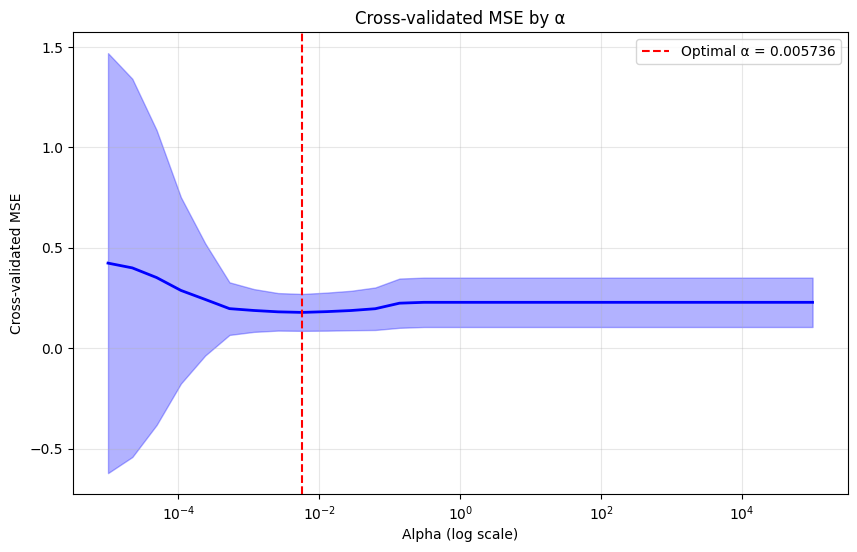

In [107]:
plt.figure(figsize=(10, 6))
plt.semilogx(lasso_cv.alphas_, lasso_cv.mse_path_.mean(axis=1), 'b-', linewidth=2)
plt.axvline(lasso_cv.alpha_, color='r', linestyle='--', label=f'Optimal α = {lasso_cv.alpha_:.6f}')
plt.fill_between(lasso_cv.alphas_,
                  lasso_cv.mse_path_.mean(axis=1) - lasso_cv.mse_path_.std(axis=1),
                  lasso_cv.mse_path_.mean(axis=1) + lasso_cv.mse_path_.std(axis=1),
                  alpha=0.3, color='blue')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Cross-validated MSE')
plt.title('Cross-validated MSE by α')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

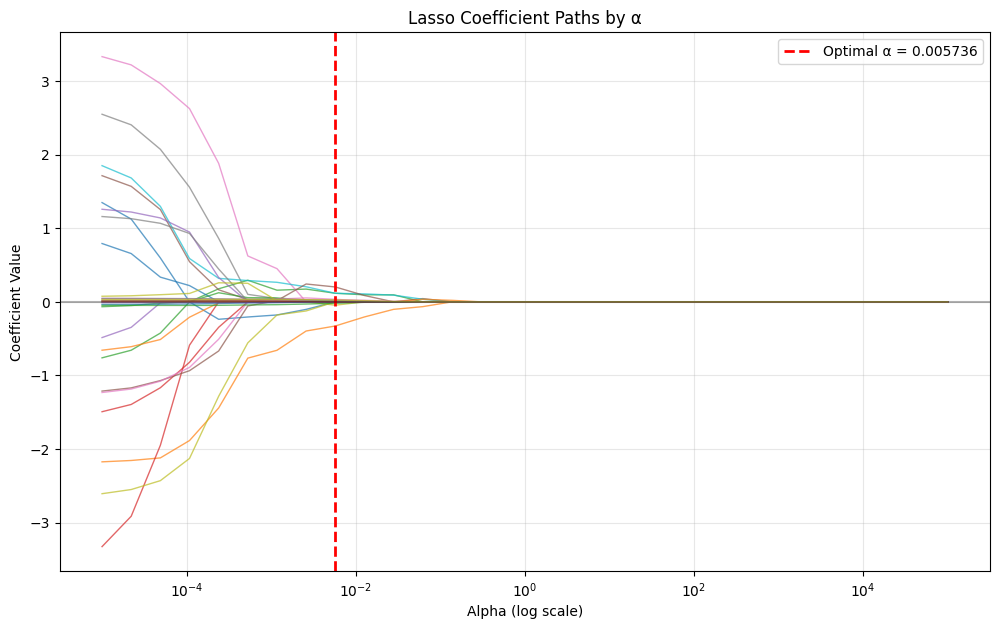

In [114]:
# Fit Lasso at each alpha
coef_paths = []
alphas_used = []

for alpha in alphas:
    lasso_temp = Lasso(alpha=alpha, random_state=42, max_iter=90000, tol=1e-3)
    lasso_temp.fit(X_scaled, y)
    coef_paths.append(lasso_temp.coef_)
    alphas_used.append(alpha)

coef_paths = np.array(coef_paths)

# Plot coefficient paths
plt.figure(figsize=(12, 7))
for i in range(len(all_feature_names)):
    plt.semilogx(alphas_used, coef_paths[:, i], linewidth=1, alpha=0.7)

plt.axvline(lasso_cv.alpha_, color='red', linestyle='--', linewidth=2, label=f'Optimal α = {lasso_cv.alpha_:.6f}')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.xlabel('Alpha (log scale)')
plt.ylabel('Coefficient Value')
plt.title('Lasso Coefficient Paths by α')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?

$$
J(b_0, b_1) = \frac{1}{n} \sum_{i=1}^n \left(\tilde{y}_i - b_0 - b_1 \tilde{x}_i \right)^2 + \alpha (b_1)^2.
$$

2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.

$b_0$:

$$
\frac{\partial J}{\partial b_0} = -\frac{2}{n} \sum_{i=1}^n \left(\tilde{y}_i - b_0 - b_1 \tilde{x}_i \right) = 0
$$

$$
\sum_{i=1}^n \tilde{y}_i - n b_0 - b_1 \sum_{i=1}^n \tilde{x}_i = 0
$$

$$
\sum \tilde{y}_i = 0, \quad \sum \tilde{x}_i = 0
$$

$$
b_0 = 0
$$

$b_1$:

$$
\frac{\partial J}{\partial b_1} = -\frac{2}{n} \sum_{i=1}^n \tilde{x}_i \left(\tilde{y}_i - b_1 \tilde{x}_i \right) + 2\alpha b_1 = 0
$$

$$
-\frac{2}{n} \left( \sum \tilde{x}_i \tilde{y}_i - b_1 \sum \tilde{x}_i^2 \right) + 2\alpha b_1 = 0
$$

$$
\frac{1}{n} \sum \tilde{x}_i \tilde{y}_i = b_1 \left( \frac{1}{n} \sum \tilde{x}_i^2 + \alpha \right)
$$

$$
b_1 = \frac{\frac{1}{n} \sum \tilde{x}_i \tilde{y}_i}{\frac{1}{n} \sum \tilde{x}_i^2 + \alpha}
$$

$$
b_1 = \frac{\sum \tilde{x}_i \tilde{y}_i}{\sum \tilde{x}_i^2 + n\alpha}
$$

3. How does increasing $\alpha$ change the slope coefficient?

Taking a look at the derivative of the objective function solved for $b_1$, increasing $\alpha$ causes the denominator to increase. This means that the slope coefficient decreases.

4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

For LASSO, the objective becomes

$$
J(b_0, b_1) = \frac{1}{n} \sum_{i=1}^n (\tilde{y}_i - b_0 - b_1 \tilde{x}_i)^2 + \alpha |b_1|,
$$

but the challenge is that $|b_1|$ is not differentiable at $b_1 = 0$, so we cannot solve it using standard derivatives. Instead, we consider subgradients, which leads to the result that if the correlation term is small enough, specifically when

$$
\left| \frac{1}{n} \sum_{i=1}^n \tilde{x}_i \tilde{y}_i \right| \le \alpha,
$$

the optimal solution is $b_1 = 0$. This shows that LASSO can set coefficients exactly to zero.